# Visualising datasets

## 0.1. Imports and load data

In [1]:
import ase.io
from pathlib import Path
import numpy as np
import importlib
import torch

import sampling_methods.descriptors as descriptors
import sampling_methods.selectors as selectors
import utils.training as training

import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

importlib.reload(descriptors)
importlib.reload(selectors)
importlib.reload(training)


<module 'utils.training' from '/home/lim_yt/X-MACE-sampling/utils/training.py'>

In [2]:
ROOT_PATH = Path.cwd()
DATA_DIR = ROOT_PATH / "../data"

# dataset for training the base model, ie foundation/pre-trained model
BASE_XYZ = DATA_DIR / "A02_propene_grid_static.xyz"
BASE_N_GEOMETRIES = 500  # number of geometries to use from the base dataset

# dataset for transfer learning
TRANSFER_XYZ = DATA_DIR / "casscf_44_propene_full.xyz"
TRANSFER_N_GEOMETRIES = 500 # number of geometries to use from the transfer dataset

OUTPUT_DIR = ROOT_PATH / "../outputs"

base_atoms_list = ase.io.read(BASE_XYZ, index=f":{BASE_N_GEOMETRIES}")
transfer_atoms_list = ase.io.read(TRANSFER_XYZ, index=f":{TRANSFER_N_GEOMETRIES}")

print("base_atoms_list length:", len(base_atoms_list))
print("transfer_atoms_list length:", len(transfer_atoms_list))


base_atoms_list length: 500
transfer_atoms_list length: 500


## 0.2. Train base model



In [3]:
base_model_training_result = training.train_model(
    base_atoms_list,
    max_epochs=10
)

base_model = base_model_training_result.model
z_table = base_model_training_result.z_table
base_history = base_model_training_result.history
base_encoder = base_model_training_result.encoder

/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3

{'stage': 'base_model', 'epoch': 1, 'train_loss': 107.93402940750121, 'valid_loss': 89.07300842285156, 'seconds': 27.04}
{'stage': 'base_model', 'epoch': 5, 'train_loss': 25.219936113357544, 'valid_loss': 24.50059341430664, 'seconds': 26.56}
{'stage': 'base_model', 'epoch': 10, 'train_loss': 21.637628936767577, 'valid_loss': 21.982149085998536, 'seconds': 28.45}

Training complete after 10 epochs
Final train loss: 21.637629
Final valid loss: 21.982149


## 0.3. Get descriptor matrix

In [6]:
DESCRIPTOR_TYPE = ["bond_lengths", "bond_angles", "energies", "encoded_energies", "soap", "acsf", "mbtr"]
DESCRIPTOR = DESCRIPTOR_TYPE[3]  # choose the descriptor type to use

# matrix of descriptors for each geometry
desc_matrix = []
for atom in transfer_atoms_list:
    desc_matrix.append(descriptors.get_descriptor(DESCRIPTOR,atom,base_encoder))
desc_matrix = np.asarray(desc_matrix)

# n*m, where n is the number of geometries and m is the dimension of the descriptor
# eg if we use bond_lengths and propene, m=2 because there's 2 CC bonds in propene
print("desc_matrix shape:", desc_matrix.shape)
print("desc_matrix unique shape:", np.unique(desc_matrix, axis=0).shape)
print("desc_matrix:\n", desc_matrix)

desc_matrix shape: (500, 4)
desc_matrix unique shape: (495, 4)
desc_matrix:
 [[ 131.29751587  219.46444702   26.34461784 -254.19104004]
 [ 131.5015564   219.8037262    26.38301277 -254.58522034]
 [ 131.50440979  219.80847168   26.38354683 -254.59074402]
 ...
 [ 131.50837708  219.81504822   26.38429832 -254.59838867]
 [ 131.51083374  219.81913757   26.3847599  -254.60313416]
 [ 131.51625061  219.82818604   26.38578606 -254.61364746]]


## 1. Distances between points

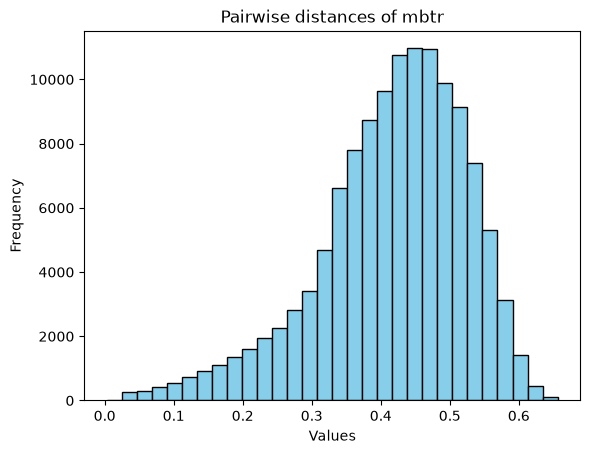

In [ ]:
# Pairwise distances

distances = pdist(desc_matrix)

plt.hist(distances, bins=30, color='skyblue', edgecolor='black')

plt.title(f'Pairwise distances of {DESCRIPTOR}')
plt.xlabel('Values')
plt.ylabel('Frequency')

plt.show()

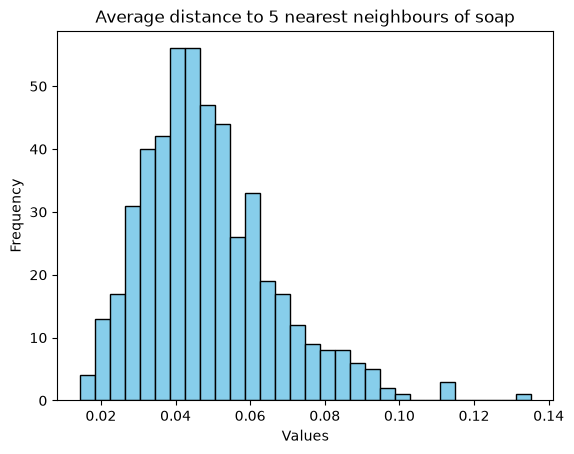

In [92]:
# Average distance to n nearest neighbours

N_NEIGHBORS = 5

nbrs = NearestNeighbors(n_neighbors=N_NEIGHBORS).fit(desc_matrix)
distances, _ = nbrs.kneighbors(desc_matrix)

avg_distances = distances.mean(axis=1)

plt.hist(avg_distances, bins=30, color='skyblue', edgecolor='black')

plt.title(f'Average distance to {N_NEIGHBORS} nearest neighbours of {DESCRIPTOR}')
plt.xlabel('Values')
plt.ylabel('Frequency')

plt.show()

## 2. PCA plot

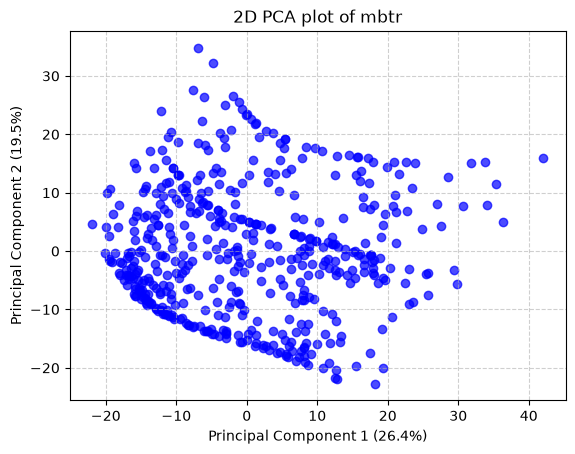

In [73]:
# 2D PCA

desc_matrix_scaled = StandardScaler().fit_transform(desc_matrix)

pca = PCA(n_components=2)
desc_matrix_pca = pca.fit_transform(desc_matrix_scaled)

plt.scatter(desc_matrix_pca[:,0], desc_matrix_pca[:,1], color='blue', marker='o', alpha=0.7)
plt.title(f'2D PCA plot of {DESCRIPTOR}')
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()


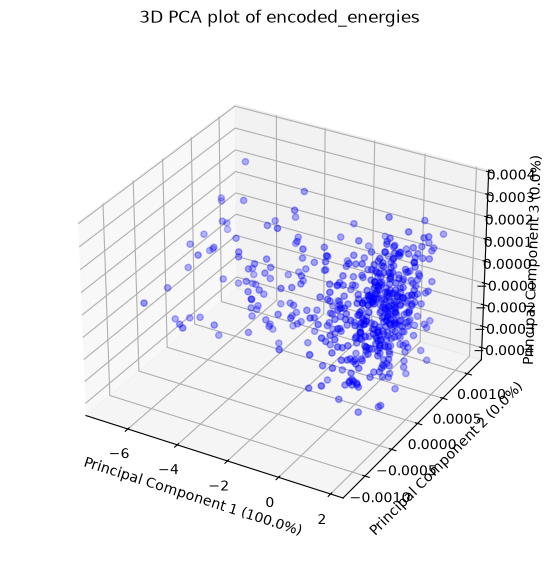

In [7]:
# 3D PCA

desc_matrix_scaled = StandardScaler().fit_transform(desc_matrix)

pca = PCA(n_components=3)
desc_matrix_pca = pca.fit_transform(desc_matrix_scaled)

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(projection='3d')
ax.set_box_aspect(None, zoom=0.85)
scatter = ax.scatter(desc_matrix_pca[:,0], desc_matrix_pca[:,1], desc_matrix_pca[:,2], color='blue', marker='o', alpha=0.7)
plt.title(f'3D PCA plot of {DESCRIPTOR}')
ax.set_xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_zlabel(f"Principal Component 3 ({pca.explained_variance_ratio_[2]*100:.1f}%)")
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()


## 3. Density

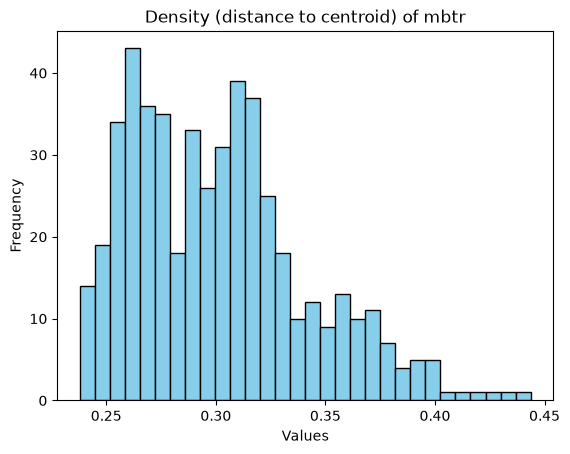

In [97]:
# Distances of all points to centroid

center = desc_matrix.mean(axis=0)
distances = np.linalg.norm(desc_matrix - center, axis=1)

plt.hist(distances, bins=30, color='skyblue', edgecolor='black')

plt.title(f'Density (distance to centroid) of {DESCRIPTOR}')
plt.xlabel('Values')
plt.ylabel('Frequency')

plt.show()


## 4. View molecules

In [11]:
from ase.visualize import view
view(base_atoms_list)

<Popen: returncode: None args: ['/home/lim_yt/micromamba/envs/xmace311/bin/p...>